In [1]:
# Upgrade and install required libraries
!pip install  caer opencv-python tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.1/320.1 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.5/224.5 kB 15.8 MB/s eta 0:00:00


In [2]:
# ===================== Core Library Imports =====================
import caer                  # Image processing and dataset handling
import os                    # Operating system path handling
import numpy as np           # Numerical computation
import cv2 as cv             # Image reading and preprocessing
import gc                    # Garbage collection for memory management
import matplotlib.pyplot as plt  # Visualization

# TensorFlow and Keras imports for model building
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (
    LearningRateScheduler,
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, Dropout, 
    Flatten, Dense, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.regularizers import l2

2026-03-04 13:13:25.973028: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772630006.166770      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772630006.227438      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772630006.664691      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772630006.664736      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772630006.664739      24 computation_placer.cc:177] computation placer alr

In [3]:

# ===================== Global Configuration Parameters =====================
# Target image size -统一调整为80x80像素 (balanced for speed and accuracy)
IMG_SIZE = (80, 80)
# Image channels: 1 for grayscale (reduces computation), 3 for RGB
channels = 1
# Dataset root path (modify for local execution)
char_path = r'/kaggle/input/datasets/alexattia/the-simpsons-characters-dataset/simpsons_dataset'

In [4]:
# ===================== Analyze Dataset and Select Target Classes =====================
# Initialize dictionary to count images per character: {character_name: image_count}
char_dict = {}

# Iterate through all character folders in the dataset directory
for char in os.listdir(char_path):
    char_folder = os.path.join(char_path, char)
    # Only process directories (skip files/hidden directories)
    if os.path.isdir(char_folder):
        # Count number of images in each character folder
        char_dict[char] = len(os.listdir(char_folder))

# Sort characters by image count in descending order
char_dict = caer.sort_dict(char_dict, descending=True)

# Select top 10 characters with most images (reduce training load, improve speed)
characters = []
count = 0
for char, _ in char_dict:
    characters.append(char)
    count += 1
    if count >= 10:
        break
# Print selected characters for verification
print("Selected characters:", characters)

Selected characters: ['homer_simpson', 'ned_flanders', 'moe_szyslak', 'lisa_simpson', 'bart_simpson', 'marge_simpson', 'krusty_the_clown', 'principal_skinner', 'charles_montgomery_burns', 'milhouse_van_houten']


In [5]:
# ===================== Load and Preprocess Training Data =====================
# Load images from directory, preprocess (resize, grayscale) and shuffle
train = caer.preprocess_from_dir(
    char_path, 
    characters, 
    channels=channels, 
    IMG_SIZE=IMG_SIZE, 
    isShuffle=True  # Shuffle data to avoid order bias
)

# Print number of training samples
print(f"Total training samples: {len(train)}")

# Separate features (images) and labels (character indices)
featureSet, labels = caer.sep_train(train, IMG_SIZE=IMG_SIZE)

[INFO] Could not find a file to load from. Generating the training data
----------------------------------------------
[INFO] At 1000 files
[INFO] At 2000 files
[INFO] 2246 files found in 3.963491678237915s
[INFO] At 1000 files
[INFO] 1454 files found in 2.9962899684906006s
[INFO] At 1000 files
[INFO] 1452 files found in 3.533726453781128s
[INFO] At 1000 files
[INFO] 1354 files found in 3.048682928085327s
[INFO] At 1000 files
[INFO] 1342 files found in 3.168513774871826s
[INFO] At 1000 files
[INFO] 1291 files found in 3.6358802318573s
[INFO] At 1000 files
[INFO] 1206 files found in 3.3041844367980957s
[INFO] At 1000 files
[INFO] 1194 files found in 3.4036717414855957s
[INFO] At 1000 files
[INFO] 1193 files found in 8.654857873916626s
[INFO] At 1000 files
[INFO] 1079 files found in 3.227177619934082s
----------------------------------------------
[INFO] 13811 files preprocessed! Took 3m 4s
Total training samples: 13811


In [6]:
# ===================== Data Normalization and One-Hot Encoding =====================
# Normalize pixel values to [0, 1] (improves model convergence)
featureSet = caer.normalize(featureSet)
# One-hot encode labels for multi-class classification
labels = to_categorical(labels, len(characters))

# Split data into training (80%) and validation (20%) sets
x_train, x_val, y_train, y_val = caer.train_val_split(
    featureSet, 
    labels, 
    val_ratio=0.2,
)

# Clean up memory by deleting unused variables
del train, featureSet, labels
gc.collect()

0

In [7]:
# ===================== Image Data Augmentation (Prevent Overfitting) =====================
# Batch size: balance between training speed and memory usage
BATCH_SIZE = 32

# Define more aggressive data augmentation for training set
train_datagen = ImageDataGenerator(
    rotation_range=30,          # Random rotation between 0-30 degrees
    width_shift_range=0.25,     # Random horizontal shift (25% of width)
    height_shift_range=0.25,    # Random vertical shift (25% of height)
    horizontal_flip=True,       # Random horizontal flip (suitable for faces)
    zoom_range=0.2,             # Random zoom (20%)
    shear_range=0.15,           # Random shear transformation
    fill_mode='nearest'         # Fill empty pixels after transformation
)

# Only normalize validation set (no augmentation to evaluate true performance)
val_datagen = ImageDataGenerator()

# Create data generators for training and validation
train_gen = train_datagen.flow(
    x_train, 
    y_train, 
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_gen = val_datagen.flow(
    x_val, 
    y_val, 
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [8]:
# ===================== Build Improved CNN Model =====================
# Number of output classes (top 10 characters)
output_dim = len(characters)
w, h = IMG_SIZE[:2]

# Build sequential CNN model with batch normalization and L2 regularization
model = Sequential(name="Simpsons_Character_Classifier")

# Input layer: match image dimensions (width, height, channels)
model.add(Input(shape=(w, h, channels), name="Input_Layer"))

# First convolutional block
model.add(Conv2D(
    32, (3, 3), 
    activation='relu', 
    padding='same',
    kernel_regularizer=l2(0.001),  # L2 regularization to prevent overfitting
    name="Conv1_1"
))
model.add(BatchNormalization(name="BN1_1"))  # Stabilize training
model.add(Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.001), name="Conv1_2"))
model.add(BatchNormalization(name="BN1_2"))
model.add(MaxPooling2D(pool_size=(2, 2), name="Pool1"))
model.add(Dropout(0.3, name="Dropout1"))  # Increased dropout for better regularization

# Second convolutional block
model.add(Conv2D(64, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001), name="Conv2_1"))
model.add(BatchNormalization(name="BN2_1"))
model.add(Conv2D(64, (3, 3), activation='relu', kernel_regularizer=l2(0.001), name="Conv2_2"))
model.add(BatchNormalization(name="BN2_2"))
model.add(MaxPooling2D(pool_size=(2, 2), name="Pool2"))
model.add(Dropout(0.3, name="Dropout2"))

# Third convolutional block (reduced filters from 256 to 128 to prevent overfitting)
model.add(Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=l2(0.001), name="Conv3_1"))
model.add(BatchNormalization(name="BN3_1"))
model.add(Conv2D(128, (3, 3), activation='relu', kernel_regularizer=l2(0.001), name="Conv3_2"))
model.add(BatchNormalization(name="BN3_2"))
model.add(MaxPooling2D(pool_size=(2, 2), name="Pool3"))
model.add(Dropout(0.3, name="Dropout3"))

# Fully connected layers
model.add(Flatten(name="Flatten"))
model.add(Dropout(0.5, name="Dropout_FC"))  # Heavy dropout for dense layer
model.add(Dense(512, activation='relu', kernel_regularizer=l2(0.001), name="Dense1"))  # Reduced units from 1024
model.add(BatchNormalization(name="BN_FC"))

# Output layer: softmax for multi-class probability distribution
model.add(Dense(output_dim, activation='softmax', name="Output_Layer"))

# Print model summary
model.summary()

I0000 00:00:1772630217.694038      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "Simpsons_Character_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Conv1_1 (Conv2D)                │ (None, 80, 80, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1_1 (BatchNormalization)      │ (None, 80, 80, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv1_2 (Conv2D)                │ (None, 78, 78, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN1_2 (BatchNormalization)      │ (None, 78, 78, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool1 (MaxPooling2D)            │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout1 (Dropout)              │ (None, 39, 39, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2_1 (Conv2D)                │ (None, 39, 39, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN2_1 (BatchNormalization)      │ (None, 39, 39, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv2_2 (Conv2D)                │ (None, 37, 37, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN2_2 (BatchNormalization)      │ (None, 37, 37, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool2 (MaxPooling2D)            │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout2 (Dropout)              │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3_1 (Conv2D)                │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN3_1 (BatchNormalization)      │ (None, 18, 18, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Conv3_2 (Conv2D)                │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN3_2 (BatchNormalization)      │ (None, 16, 16, 128)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Pool3 (MaxPooling2D)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout3 (Dropout)              │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_FC (Dropout)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense1 (Dense)                  │ (None, 512)            │     4,194,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_FC (BatchNormalization)      │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Layer (Dense)            │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,490,218 (17.13 MB)

 Trainable params: 4,488,298 (17.12 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [9]:
# ===================== Configure Training Optimizer and Callbacks =====================
# Use Adam optimizer (better convergence than SGD for this task)
optimizer = Adam(
    learning_rate=0.001,  # Initial learning rate
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

# Compile model
model.compile(
    loss='categorical_crossentropy',  # Loss function for multi-class classification
    optimizer=optimizer,
    metrics=['accuracy']              # Track accuracy during training
)

# Define callbacks to improve training
callbacks = [
    # Early stopping: stop training if validation loss doesn't improve for 8 epochs
    EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True,  # Restore weights from best epoch
        verbose=1
    ),
    # Reduce learning rate when validation accuracy plateaus
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,  # Reduce LR by 50%
        patience=3,
        min_lr=1e-6,  # Minimum learning rate
        verbose=1
    ),
    # Save best model during training
    ModelCheckpoint(
        'best_simpsons_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Set training epochs (increased from 10, early stopping will prevent overtraining)
EPOCHS = 30

In [10]:
# ===================== Start Model Training =====================
print("\nStarting model training...")
training_history = model.fit(
    train_gen,
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_gen,
    validation_steps=len(x_val) // BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)


Starting model training...
Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1772630224.021243      76 service.cc:152] XLA service 0x799b18003ab0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772630224.021281      76 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772630224.940380      76 cuda_dnn.cc:529] Loaded cuDNN version 91002


  7/345 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.1124 - loss: 4.6000

I0000 00:00:1772630232.601894      76 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


343/345 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.1716 - loss: 4.2724
Epoch 1: val_accuracy improved from -inf to 0.13372, saving model to best_simpsons_model.h5


...

345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.5808 - loss: 1.9711 - val_accuracy: 0.7253 - val_loss: 1.5451 - learning_rate: 5.0000e-04
Epoch 18/30
  1/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6250 - loss: 1.8077
Epoch 18: val_accuracy did not improve from 0.72529
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6250 - loss: 1.8077 - val_accuracy: 0.7220 - val_loss: 1.5658 - learning_rate: 5.0000e-04
Epoch 19/30
343/345 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6247 - loss: 1.8728
Epoch 19: val_accuracy did not improve from 0.72529
345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.6247 - loss: 1.8727 - val_accuracy: 0.5872 - val_loss: 2.1696 - learning_rate: 5.0000e-04
Epoch 20/30
  1/345 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.5625 - loss: 1.8213
Epoch 20: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 20: val_accuracy did not improve from 0.72529
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5625 - los

345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6713 - loss: 1.7317 - val_accuracy: 0.8056 - val_loss: 1.2795 - learning_rate: 2.5000e-04
Epoch 22/30
  1/345 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.5625 - loss: 1.9150
Epoch 22: val_accuracy did not improve from 0.80560
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5625 - loss: 1.9150 - val_accuracy: 0.8034 - val_loss: 1.2816 - learning_rate: 2.5000e-04
Epoch 23/30
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6951 - loss: 1.5921
Epoch 23: val_accuracy improved from 0.80560 to 0.82267, saving model to best_simpsons_model.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 27ms/step - accuracy: 0.6951 - loss: 1.5921 - val_accuracy: 0.8227 - val_loss: 1.1925 - learning_rate: 2.5000e-04
Epoch 24/30
  1/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7812 - loss: 1.5267
Epoch 24: val_accuracy improved from 0.82267 to 0.82558, saving model to best_simpsons_model.h5


345/345 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7812 - loss: 1.5267 - val_accuracy: 0.8256 - val_loss: 1.1815 - learning_rate: 2.5000e-04
Epoch 25/30
343/345 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7163 - loss: 1.4951
Epoch 25: val_accuracy did not improve from 0.82558
345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7163 - loss: 1.4950 - val_accuracy: 0.7863 - val_loss: 1.2534 - learning_rate: 2.5000e-04
Epoch 26/30
  1/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7500 - loss: 1.3280
Epoch 26: val_accuracy did not improve from 0.82558
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7500 - loss: 1.3280 - val_accuracy: 0.7845 - val_loss: 1.2576 - learning_rate: 2.5000e-04
Epoch 27/30
343/345 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7216 - loss: 1.4622
Epoch 27: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 27: val_accuracy did not improve from 0.82558
345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7216 - los

345/345 ━━━━━━━━━━━━━━━━━━━━ 9s 26ms/step - accuracy: 0.7519 - loss: 1.3570 - val_accuracy: 0.8517 - val_loss: 1.0216 - learning_rate: 1.2500e-04
Epoch 30/30
  1/345 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6875 - loss: 1.4002
Epoch 30: val_accuracy did not improve from 0.85174
345/345 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6875 - loss: 1.4002 - val_accuracy: 0.8514 - val_loss: 1.0207 - learning_rate: 1.2500e-04
Restoring model weights from the end of the best epoch: 30.


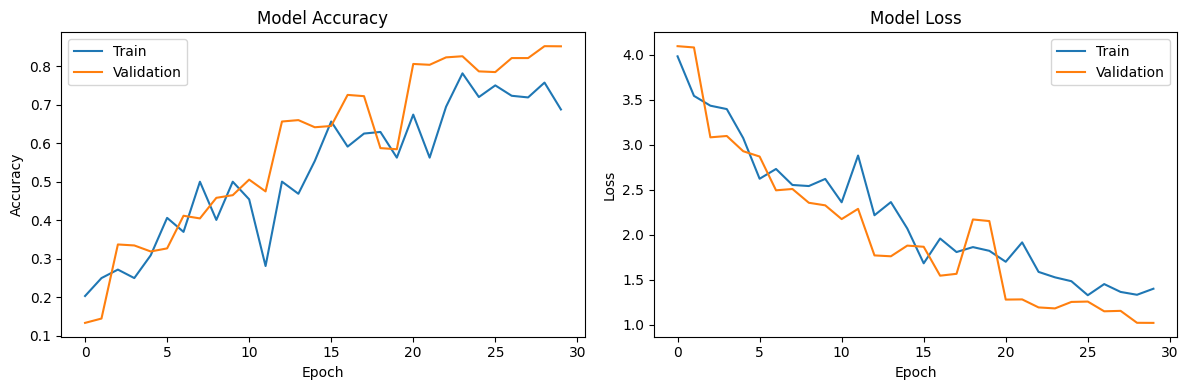

In [11]:
# ===================== Visualize Training Results =====================
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(training_history.history['loss'])
plt.plot(training_history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper right')

plt.tight_layout()
plt.show()


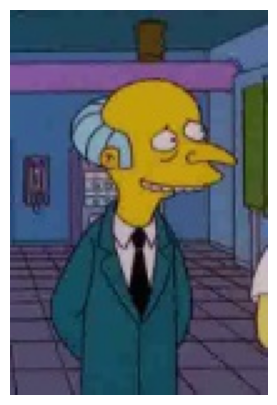


Predicted Character: charles_montgomery_burns
Confidence Score: 97.59%


In [12]:
# ===================== Test Model with Single Image =====================
# Test image path (replace with your own image path)
test_path = r'/kaggle/input/datasets/alexattia/the-simpsons-characters-dataset/kaggle_simpson_testset/kaggle_simpson_testset/charles_montgomery_burns_0.jpg'

# Read test image (OpenCV reads in BGR format)
img = cv.imread(test_path)
if img is None:
    print("Error: Could not read test image")
else:
    # Visualize original test image
    plt.figure(figsize=(5, 5))
    plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))  # Convert BGR to RGB for correct display
    plt.axis('off')
    plt.show()

    # Preprocessing function for test images (must match training preprocessing)
    def prepare_image(image):
        """
        Preprocess test image to match model input requirements
        Args:
            image: Original BGR image from OpenCV
        Returns:
            Processed image tensor ready for model prediction
        """
        # Convert to grayscale
        gray_img = cv.cvtColor(image, cv.COLOR_BGR2GRAY)
        # Resize to target size
        resized_img = cv.resize(gray_img, IMG_SIZE)
        # Normalize pixel values to [0, 1]
        normalized_img = resized_img.astype('float32') / 255.0
        # Add channel dimension: (80,80) → (80,80,1)
        img_with_channel = np.expand_dims(normalized_img, axis=-1)
        # Add batch dimension: (80,80,1) → (1,80,80,1) (required by model)
        img_with_batch = np.expand_dims(img_with_channel, axis=0)
        return img_with_batch

    # Preprocess test image
    processed_img = prepare_image(img)
    # Make prediction (returns probability for each class)
    predictions = model.predict(processed_img, verbose=0)
    # Get index of class with highest probability
    pred_index = np.argmax(predictions[0])
    # Map index to character name
    pred_char = characters[pred_index]
    # Get confidence score
    confidence = predictions[0][pred_index] * 100

    # Print prediction result
    print(f"\nPredicted Character: {pred_char}")
    print(f"Confidence Score: {confidence:.2f}%")